In [1]:
# Import necessary libraries

# Basic libraries for numerical operations, data manipulation, and visualization
import numpy as np  # For numerical computations
import pandas as pd  # For data manipulation and analysis
import seaborn as sns  # For statistical data visualization
import matplotlib.pyplot as plt  # For creating plots and figures
import warnings  # To handle warnings in the code
warnings.filterwarnings('ignore')  # Ignore warnings to reduce clutter

# Data Preprocessing and Feature Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # For feature scaling (Standard and Min-Max scaling)

# Data Splitting and Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,cross_validate  # For splitting data, cross-validation, and hyperparameter tuning
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  # For model evaluation and performance metrics

# Handling Imbalanced Datasets
from imblearn.over_sampling import SMOTE  # For handling imbalanced datasets
# Machine Learning Models (for classification)
from sklearn.linear_model import LogisticRegression  # Logistic Regression for binary classification
from sklearn.neural_network import MLPClassifier  # Multi-layer Perceptron (Neural Network) for classification
from sklearn.svm import SVC  # Support Vector Machine classifier
from sklearn.ensemble import (
    RandomForestClassifier,  # Random Forest classifier
    GradientBoostingClassifier,  # Gradient Boosting classifier
    AdaBoostClassifier,  # AdaBoost classifier
    ExtraTreesClassifier,
    StackingClassifier,  # Stacking classifier
    VotingClassifier  # Voting classifier
)
from xgboost import XGBClassifier  # XGBoost classifier

# Model Interpretability (SHAP)
import shap

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier


In [3]:
df = pd.read_csv("merged_dataset_sample_1.csv")

In [4]:
df.head()

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,HadHeartAttack,HadAngina,HadStroke,...,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,SystolicBP,DiastolicBP,Cholesterol,PrematureFamilyHistory
0,1,2,0,0,3,1,7,1,0,0,...,0,1,1,1,0,0,113,82,197,1
1,1,4,1,0,0,1,7,0,0,0,...,0,1,0,0,0,2,106,77,190,1
2,1,2,0,0,3,1,6,1,1,0,...,0,1,1,2,0,0,127,86,214,0
3,0,4,3,30,3,1,5,0,0,0,...,1,1,1,1,0,2,114,72,202,1
4,0,0,7,0,3,1,8,1,0,0,...,0,0,1,2,0,0,130,91,207,0


In [5]:

# Extract feature names
feature_names = df.columns.tolist()

# Print the feature names
print("Feature Names:", feature_names)


Feature Names: ['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ChestScan', 'AgeCategory', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos', 'SystolicBP', 'DiastolicBP', 'Cholesterol', 'PrematureFamilyHistory']


In [6]:
from sklearn.model_selection import train_test_split, cross_val_score,cross_validate
x = df.drop('HadHeartAttack',axis = 1)
y = df['HadHeartAttack']
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=.2,stratify=y)

In [7]:
# Let us first distingush datasets into num and object
num = []
cat = []
for i,col in enumerate(df.columns):
    if df[col].nunique() > 5:
        num.append(col)
    else:
        cat.append(col)
        df[col] = df[col].astype('object')

In [8]:
cat_f=df[cat].drop('HadHeartAttack',axis=1)

In [9]:
num_f = df[num]

In [10]:
num_f

,PhysicalHealthDays,MentalHealthDays,SleepHours,AgeCategory,BMI,SystolicBP,DiastolicBP,Cholesterol
0,0,0,7,11,22.71,113,82,197
1,1,0,7,3,22.24,106,77,190
2,0,0,6,11,34.18,127,86,214
3,3,30,5,6,51.49,114,72,202
4,7,0,8,11,23.23,130,91,207
...,...,...,...,...,...,...,...,...
27111,7,0,5,12,19.69,98,75,159
27112,0,0,6,8,28.29,136,90,237
27113,0,30,6,8,21.93,112,74,189
27114,15,30,10,11,21.70,126,82,181


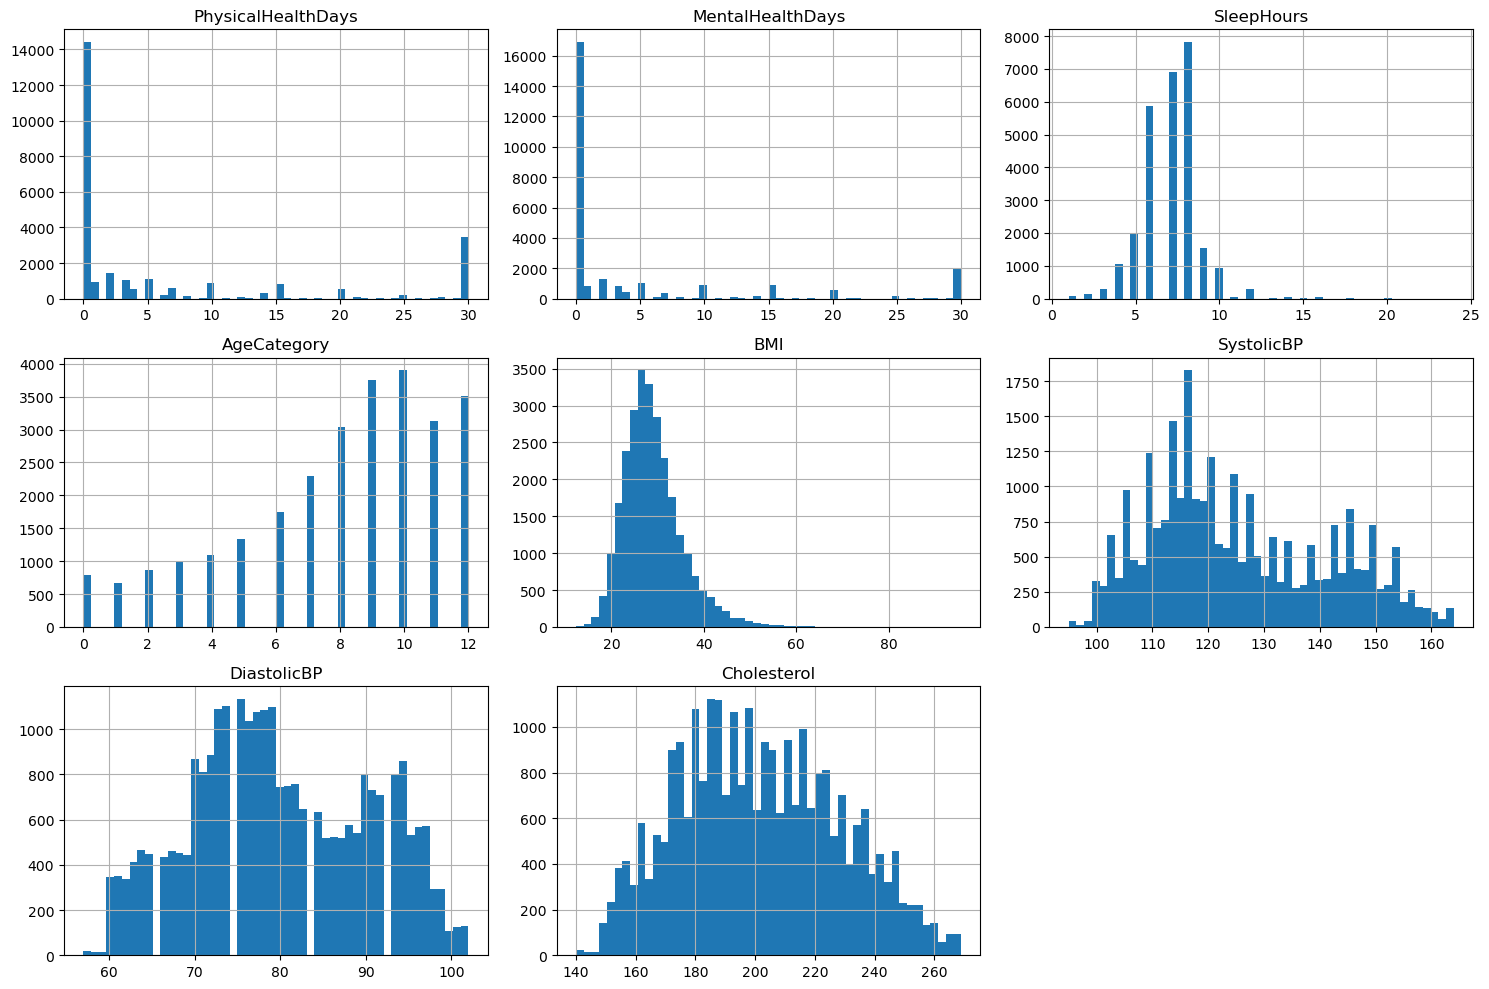

In [11]:
import matplotlib.pyplot as plt

# Generate histograms for numeric columns
df.select_dtypes(['float', 'int']).hist(bins=50, figsize=(15, 10))

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure to a file
plt.savefig('histogram_output 2.png')  # You can change the filename and format as needed

# Display the plot
plt.show()


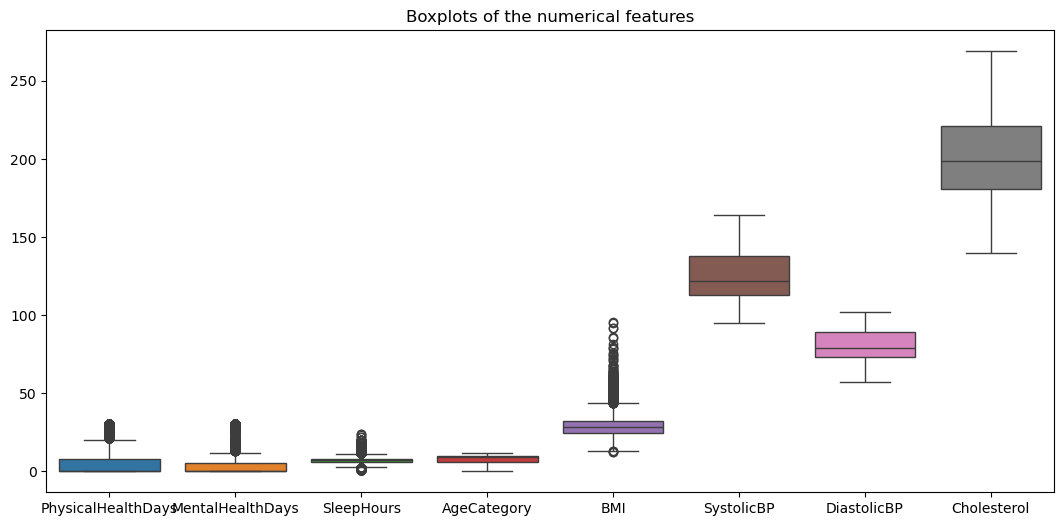

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size for better readability
plt.figure(figsize=(13, 6))

# Create boxplots for 'BMI' and 'SleepHours'
sns.boxplot(num_f)

# Set the title of the plot
plt.title('Boxplots of the numerical features')
plt.savefig('Boxplots  ') 
# Display the plot
plt.show()


In [13]:
import numpy as np

# Loop through each numerical column in the dataframe num_f
for column in num_f.columns:
    # Calculate Z-scores for the column
    z = np.abs((num_f[column] - num_f[column].mean()) / num_f[column].std())
    
    # Set the threshold for outliers (Z-score > 3)
    outliers = num_f[column][z > 3]
    
    # Print the outliers for the current column
    if not outliers.empty:
        print(f"Outliers detected in {column}:")
        print(outliers)
        print("\n")
    else:
        print(f"No outliers detected in {column}.")
        print("\n")


No outliers detected in PhysicalHealthDays.


No outliers detected in MentalHealthDays.


Outliers detected in SleepHours:
139      18
181       1
541       1
877      18
1023     19
         ..
26075     1
26084    20
26191    16
26239    20
26898     1
Name: SleepHours, Length: 241, dtype: int64


No outliers detected in AgeCategory.


Outliers detected in BMI:
3        51.49
32       52.90
140      57.39
266      49.23
371      49.13
         ...  
26851    48.66
26872    48.82
26874    52.13
26929    63.77
27082    52.73
Name: BMI, Length: 341, dtype: float64


No outliers detected in SystolicBP.


No outliers detected in DiastolicBP.


No outliers detected in Cholesterol.




In [14]:
import pandas as pd
import numpy as np

# Initialize an empty list to store outlier information
outlier_data = []

# Loop through each numerical column in the dataframe num_f
for column in num_f.select_dtypes(include=[np.number]).columns:
    # Calculate Z-scores for the column
    z = np.abs((num_f[column] - num_f[column].mean()) / num_f[column].std())
    
    # Identify outliers (Z-score > 3)
    outliers = num_f[z > 3][column]
    
    # Append outlier information to the list
    for index, value in outliers.items():
        outlier_data.append({'Column': column, 'Index': index, 'Value': value})

# Create a DataFrame from the outlier data
outliers_df = pd.DataFrame(outlier_data)

# Display the outliers DataFrame
print(outliers_df)


         Column  Index  Value
0    SleepHours    139  18.00
1    SleepHours    181   1.00
2    SleepHours    541   1.00
3    SleepHours    877  18.00
4    SleepHours   1023  19.00
..          ...    ...    ...
577         BMI  26851  48.66
578         BMI  26872  48.82
579         BMI  26874  52.13
580         BMI  26929  63.77
581         BMI  27082  52.73

[582 rows x 3 columns]


In [15]:
# Function to cap outliers beyond 3 standard deviations
def cap_outliers(df, column):
    mean = df[column].mean()
    std_dev = df[column].std()
    lower_bound = mean - 3 * std_dev
    upper_bound = mean + 3 * std_dev
    df[column] = np.clip(df[column], lower_bound, upper_bound)
df_cleaned = num_f.copy()

# BMI - Replace '0' values with median (if there are any '0' values)
BMI_median = df_cleaned['BMI'][df_cleaned['BMI'] != 0].median()
df_cleaned['BMI'] = df_cleaned['BMI'].replace(0, BMI_median)

# Sleephours - Replace '0' values with median (if applicable)
SleepHours_median = df_cleaned['SleepHours'][df_cleaned['SleepHours'] != 0].median()
df_cleaned['SleepHours'] = df_cleaned['SleepHours'].replace(0,SleepHours_median)

# Print the summary to verify the replacement
print(f"New BMI median after imputation: {BMI_median}")
print(f"New Sleephours median after imputation: {SleepHours_median}")

New BMI median after imputation: 28.06
New Sleephours median after imputation: 7.0


In [16]:
# Re-use the cap_outliers function to cap values for these features
cap_outliers(df_cleaned, 'BMI')
cap_outliers(df_cleaned, 'SleepHours')

# Check the summary statistics after capping
print(df_cleaned[['BMI', 'SleepHours']].describe())


                BMI    SleepHours
count  27116.000000  27116.000000
mean      28.936644      7.032893
std        6.210552      1.581411
min       12.340000      1.988988
25%       24.560000      6.000000
50%       28.060000      7.000000
75%       32.280000      8.000000
max       48.646173     12.112059


In [17]:
df_cleaned

,PhysicalHealthDays,MentalHealthDays,SleepHours,AgeCategory,BMI,SystolicBP,DiastolicBP,Cholesterol
0,0,0,7.0,11,22.710000,113,82,197
1,1,0,7.0,3,22.240000,106,77,190
2,0,0,6.0,11,34.180000,127,86,214
3,3,30,5.0,6,48.646173,114,72,202
4,7,0,8.0,11,23.230000,130,91,207
...,...,...,...,...,...,...,...,...
27111,7,0,5.0,12,19.690000,98,75,159
27112,0,0,6.0,8,28.290000,136,90,237
27113,0,30,6.0,8,21.930000,112,74,189
27114,15,30,10.0,11,21.700000,126,82,181


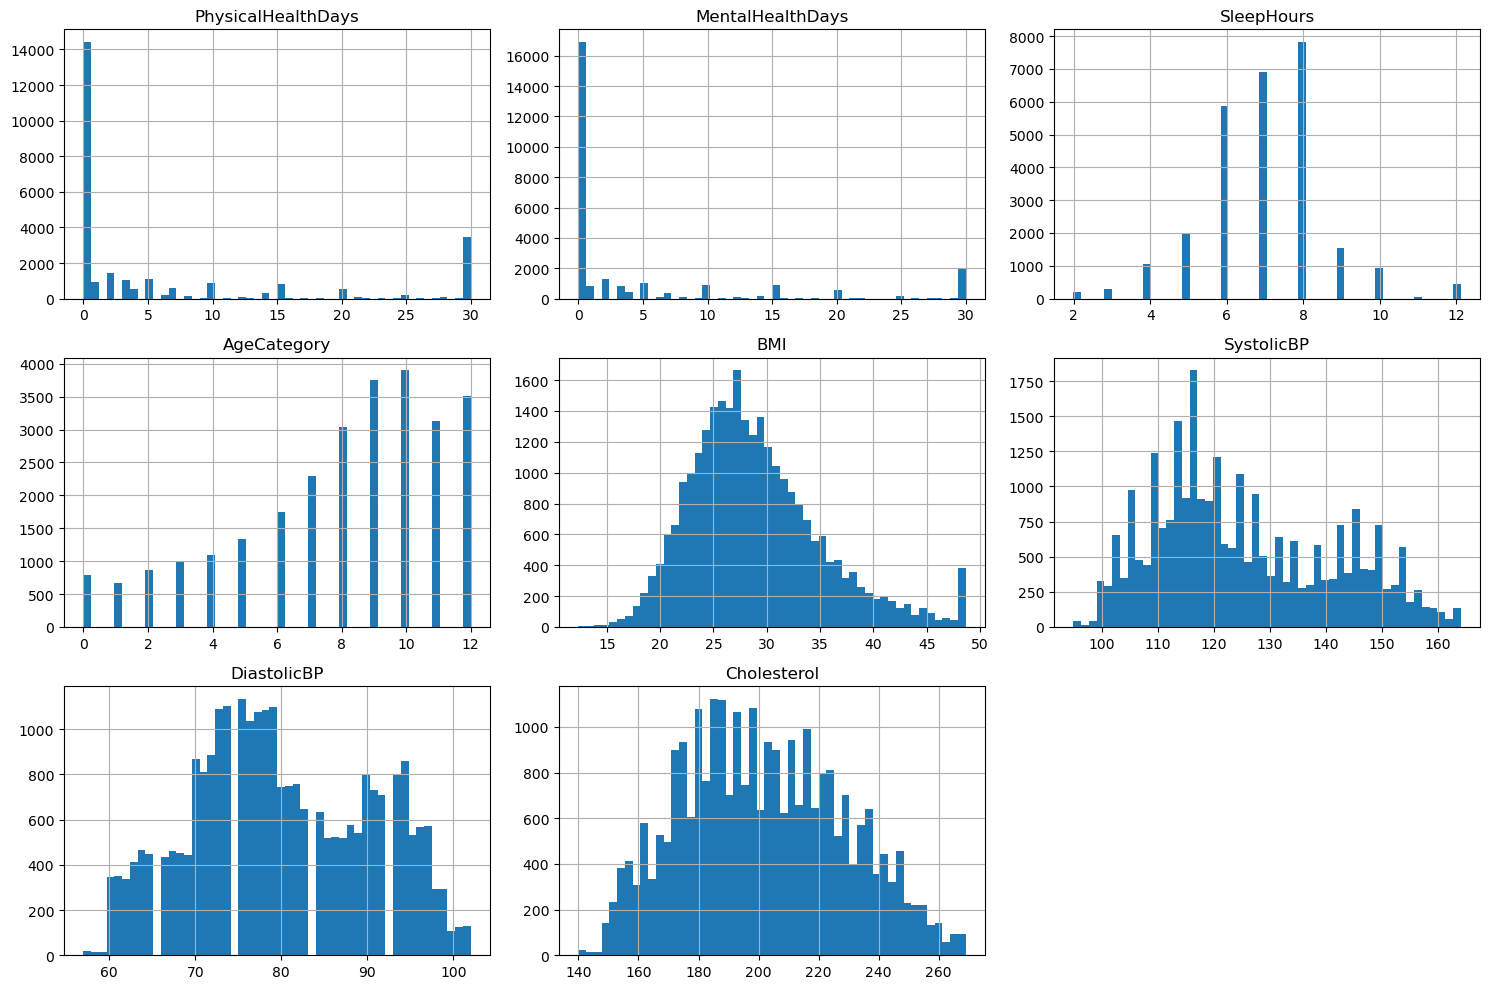

In [18]:
import matplotlib.pyplot as plt

# Generate histograms for numeric columns
df_cleaned.select_dtypes(['float', 'int']).hist(bins=50, figsize=(15, 10))

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure to a file
plt.savefig('histogram_output 3.png')  # You can change the filename and format as needed

# Display the plot
plt.show()

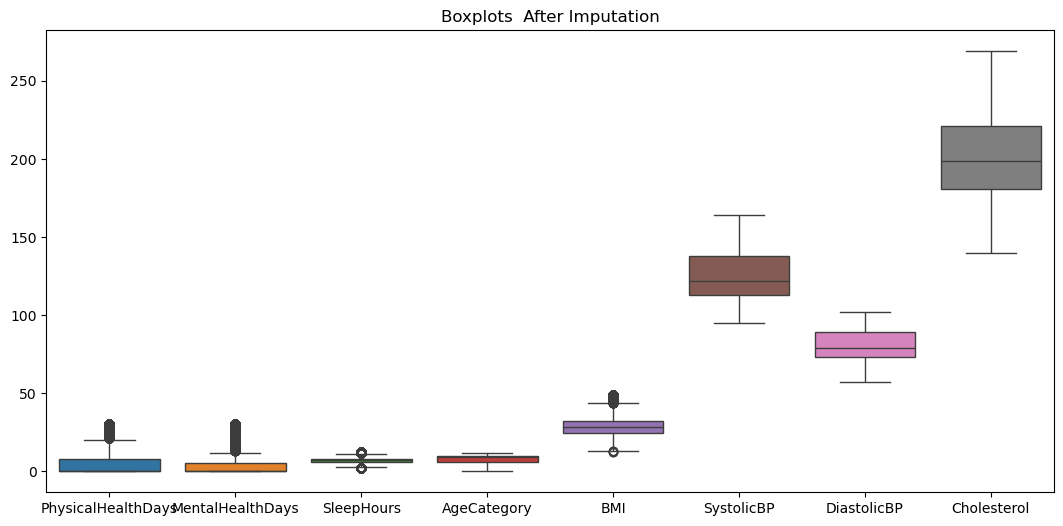

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size for better readability
plt.figure(figsize=(13, 6))

# Create boxplots for 'BMI' and 'SleepHours'
sns.boxplot(df_cleaned)

# Set the title of the plot
plt.title('Boxplots  After Imputation')
plt.savefig('Boxplots  After capoutlier') 
# Display the plot
plt.show()


       BMI  SleepHours
0  22.7100         7.0
1  22.2400         7.0
2  34.1800         6.0
3  27.6938         5.0
4  23.2300         8.0


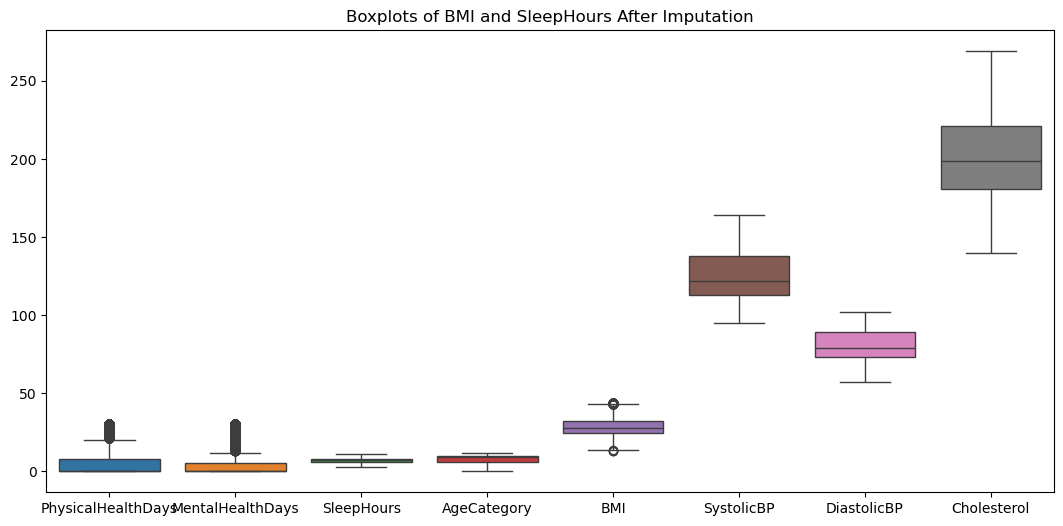

In [20]:
from sklearn.ensemble import RandomForestRegressor
# Function to identify outliers using the IQR method
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)].index

# Identify outliers in 'BMI' and 'SleepHours'
bmi_outliers = find_outliers_iqr(df_cleaned, 'BMI')
sleephours_outliers = find_outliers_iqr(df_cleaned, 'SleepHours')

# Replace outliers with NaN for imputation
df_cleaned.loc[bmi_outliers, 'BMI'] = np.nan
df_cleaned.loc[sleephours_outliers, 'SleepHours'] = np.nan

# Prepare data for imputation
# Drop rows with NaN to train the model
non_outlier_data = df_cleaned.dropna()

# Features excluding 'BMI' and 'SleepHours'
X_train = non_outlier_data.drop(columns=['BMI', 'SleepHours'])

# Targets for imputation
y_bmi = non_outlier_data['BMI']
y_sleephours = non_outlier_data['SleepHours']

# Impute 'BMI' using RandomForestRegressor
rf_bmi = RandomForestRegressor(random_state=0)
rf_bmi.fit(X_train, y_bmi)

# Predict missing 'BMI' values
if df_cleaned['BMI'].isna().sum() > 0:
    X_test_bmi = df_cleaned[df_cleaned['BMI'].isna()].drop(columns=['BMI', 'SleepHours'])
    df_cleaned.loc[df_cleaned['BMI'].isna(), 'BMI'] = rf_bmi.predict(X_test_bmi)

# Impute 'SleepHours' using RandomForestRegressor
rf_sleephours = RandomForestRegressor(random_state=0)
rf_sleephours.fit(X_train, y_sleephours)

# Predict missing 'SleepHours' values
if df_cleaned['SleepHours'].isna().sum() > 0:
    X_test_sleephours = df_cleaned[df_cleaned['SleepHours'].isna()].drop(columns=['BMI', 'SleepHours'])
    df_cleaned.loc[df_cleaned['SleepHours'].isna(), 'SleepHours'] = rf_sleephours.predict(X_test_sleephours)

# Display the imputed values
print(df_cleaned[['BMI', 'SleepHours']].head())

# Visualize the distributions after imputation
plt.figure(figsize=(13, 6))
sns.boxplot(df_cleaned)
plt.title('Boxplots of BMI and SleepHours After Imputation')
plt.savefig('Boxplots  After find outlier') 
plt.show()


In [21]:
data = pd.concat([df_cleaned, cat_f, df['HadHeartAttack']],axis = 1)

In [22]:
data.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,AgeCategory,BMI,SystolicBP,DiastolicBP,Cholesterol
count,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000
mean,6.526147,4.686938,6.983171,7.990153,28.505821,125.235765,79.991481,201.442433
std,10.483165,8.921903,1.379656,3.222674,5.415479,15.737771,10.354351,26.798076
min,0.000000,0.000000,3.000000,0.000000,13.290000,95.000000,57.000000,140.000000
25%,0.000000,0.000000,6.000000,6.000000,24.560000,113.000000,73.000000,181.000000
50%,0.000000,0.000000,7.000000,9.000000,27.990000,122.000000,79.000000,199.000000
75%,8.000000,5.000000,8.000000,10.000000,31.960000,138.000000,89.000000,221.000000
max,30.000000,30.000000,11.000000,12.000000,43.850000,164.000000,102.000000,269.000000


### Save Clean Dataset

In [23]:
import pandas as pd

# Assuming 'df_cleaned' is your cleaned DataFrame
data.to_csv('cleaned_data.csv', index=False)


In [24]:
df = pd.read_csv("cleaned_data.csv")

In [25]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,AgeCategory,BMI,SystolicBP,DiastolicBP,Cholesterol,Sex,GeneralHealth,...,ChestScan,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,PrematureFamilyHistory,HadHeartAttack
count,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,...,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000,27116.000000
mean,6.526147,4.686938,6.983171,7.990153,28.505821,125.235765,79.991481,201.442433,0.550524,2.207368,...,0.600826,0.455709,0.330727,0.555945,0.519288,1.113217,0.035846,0.584931,0.297205,0.495464
std,10.483165,8.921903,1.379656,3.222674,5.415479,15.737771,10.354351,26.798076,0.497450,1.316416,...,0.489738,0.498044,0.470484,0.496869,0.499637,1.004589,0.185909,0.897091,0.457036,0.499989
min,0.000000,0.000000,3.000000,0.000000,13.290000,95.000000,57.000000,140.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,6.000000,6.000000,24.560000,113.000000,73.000000,181.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,7.000000,9.000000,27.990000,122.000000,79.000000,199.000000,1.000000,2.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,5.000000,8.000000,10.000000,31.960000,138.000000,89.000000,221.000000,1.000000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,2.000000,1.000000,1.000000
max,30.000000,30.000000,11.000000,12.000000,43.850000,164.000000,102.000000,269.000000,1.000000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000,1.000000,1.000000
